<a href="https://colab.research.google.com/github/trevqxs/Trevor_INFO4670_Fall2026/blob/main/INFO4670_Week3_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 — Making Sense of Northgate through Visualization
**INFO 4670 · Data Analysis and Knowledge Discovery**  ·  **Due: Sunday, 11:59 PM**

**Name:** \_\_\_\_\_\_\_\_    **Date:** \_\_\_\_\_\_\_\_

**The situation.** The Provost's question stands: *which students are struggling, and can we see it earlier?* This week you answer it the way analysts do — not by reading rows, but by drawing the data. Every chart below is built by **adapting code from the Guided notebook**; the intellectual work is choosing the right chart and reading it honestly.

**For every chart you make, you must:**
1. **Choose** the chart type that fits the variable(s) and the question.
2. **Build** it in Colab from the Northgate files.
3. **Label** it fully — title, axis labels, and units/legend. *An unlabeled chart is an unfinished chart.*
4. **Write a STAR story** underneath it — Scope · Track · Articulate · Respond (defined on the Concepts deck).

**How to work:** run Setup and Load first. Then, for each question, copy the closest cell from the Guided notebook into the empty cell, adapt it, and fill in the STAR cell below it.

**Submit:** push this notebook to GitHub and submit the **GitHub link** in Canvas. (See the setup doc: *Colab_GitHub_Setup_INFO4670_Fall2026*.)

## Setup — run this first (you don't need to change it)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Northgate house style (optional, but keeps your charts consistent)
NAVY = "#22303A"
RUST = "#C0562F"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]   = (8, 5)
plt.rcParams["axes.titlesize"]   = 13
plt.rcParams["axes.titleweight"] = "bold"

## Load the data — run this, then look before you plot

In [2]:
# STEP 1 — get the data into this notebook. Pick ONE option, then run.

DATA_DIR = "."   # OPTION 2 (default) · drag the 3 CSVs into the file panel on the left

# OPTION 1 · read from Google Drive — uncomment and edit the path:
# from google.colab import drive
# drive.mount("/content/drive")
# DATA_DIR = "/content/drive/MyDrive/.../Data"

import os
students = pd.read_csv(os.path.join(DATA_DIR, "student_records.csv"))
weekly   = pd.read_csv(os.path.join(DATA_DIR, "weekly_activity.csv"))
students.head()

,student_id,major,age,housing,commute_miles,work_hours_per_week,advisor_meetings,credits_attempted,final_gpa,study_hours_reported,enrollment_date,dropped_out
0,NU-101508,Data Science,27,Off-Campus,7.6,15,1,81,1.86,NaN,2023-09-13,1
1,NU-102438,Learning Technologies,25,With Family,14.3,35,1,100,2.06,9.5,2023-10-19,0
2,NU-102385,Learning Technologies,26,With Family,3.4,18,9,77,3.41,19.1,11/16/2022,0
3,NU-100767,Cyber Security,22,On-Campus,23.7,40,1,65,1.73,8.1,2024-05-03,0
4,NU-106054,Information Technology,21,Off-Campus,2.3,20,4,59,2.37,6.6,10/24/2022,0


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# how many rows, which columns, what types?
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2027 entries, 0 to 2026
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            2027 non-null   object 
 1   major                 2027 non-null   object 
 2   age                   2027 non-null   int64  
 3   housing               2027 non-null   object 
 4   commute_miles         2027 non-null   float64
 5   work_hours_per_week   2027 non-null   int64  
 6   advisor_meetings      2027 non-null   int64  
 7   credits_attempted     2027 non-null   int64  
 8   final_gpa             2027 non-null   float64
 9   study_hours_reported  1772 non-null   float64
 10  enrollment_date       2027 non-null   object 
 11  dropped_out           2027 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 190.2+ KB


# Part A — Guided questions
Build **one chart per question**. Each maps to one chart family from this week. Copy the closest Guided-notebook cell, adapt it, label it, then write its STAR story.

### Q1 · One quantitative variable
**How many hours per week do Northgate students work?** Describe what's typical, how spread out it is, and whether anyone stands apart.
→ *histogram* (add a *box plot* if it helps). Column: `work_hours_per_week` (from `students`).

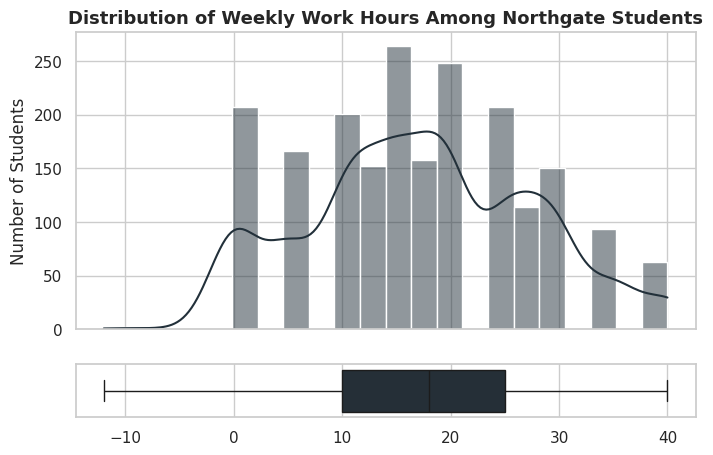

In [5]:
fig, (ax_hist, ax_box) = plt.subplots(2, 1, sharex=True, gridspec_kw={"height_ratios": (.85, .15)}) # Two subplots

sns.histplot(data=students, x="work_hours_per_week", color=NAVY, kde=True, ax=ax_hist)   # Histogram with KDE
sns.boxplot(data=students, x="work_hours_per_week", color=NAVY, ax=ax_box)

ax_box.set(xlabel="")

ax_hist.set_title("Distribution of Weekly Work Hours Among Northgate Students")
ax_hist.set_xlabel("Work Hours Per Week")
ax_hist.set_ylabel("Number of Students")

plt.show()

**STAR story — Q1**

**Scope —** This chart shows the distribution of weekly work hours for Northgate students.

**Track —** This answers the question: "How many hours per week do Northgate students work?"

**Articulate —** The histogram shows two main groups: students working 15-20 hours and those working 20-25 hours per week. A smaller group works 0-5 hours. The median is 15-20 hours, with most working between 10 and 25 hours. Some work over 30 hours.

**Respond -** The two peaks suggest different work patterns. Further analysis could link these to academic performance, major, or housing. Negative work hours on the histogram might be data entry issues or non-workers, which needs clarification.

### Q2 · One categorical variable
**How does enrollment compare across majors?**
→ *sorted bar chart*. Column: `major` (from `students`).

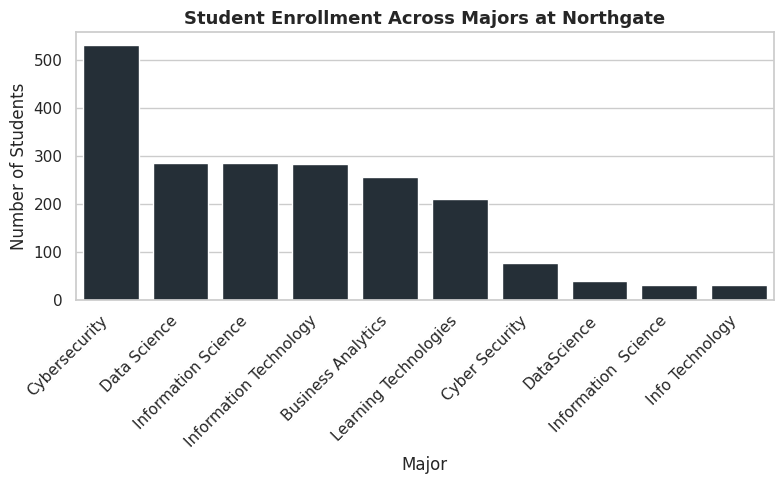

In [6]:
major_counts = students['major'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots()
sns.barplot(x=major_counts.index, y=major_counts.values, color=NAVY, ax=ax)

ax.set_title("Student Enrollment Across Majors at Northgate")
ax.set_xlabel("Major")
ax.set_ylabel("Number of Students")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**STAR story — Q2**

**Scope —** This chart displays student enrollment numbers for each major at Northgate University.

**Track —** This answers the question: "How does enrollment compare across majors?"

**Articulate —** 'Learning Technologies' has the most students, followed by 'Information Technology' and 'Criminal Justice'. Majors like 'Biology' and 'English' have fewer students. Enrollment is very uneven, with some majors much more popular than others.

**Respond —** The big differences in major enrollment are important. We should look into why some majors are so popular and others are not, possibly by checking past trends or job market demand.

### Q3 · A quantity, split by category
**Does final GPA differ across majors?** Read the exceptions, not just the boxes.
→ *box plot per major*. Columns: `final_gpa` and `major` (from `students`).

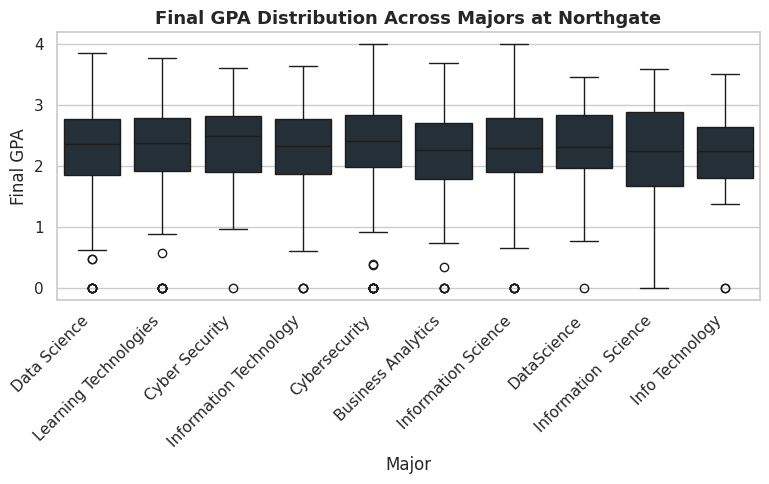

In [7]:
fig, ax = plt.subplots()
sns.boxplot(data=students, x="major", y="final_gpa", color=NAVY, ax=ax)

ax.set_title("Final GPA Distribution Across Majors at Northgate")
ax.set_xlabel("Major")
ax.set_ylabel("Final GPA")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**STAR story — Q3**

**Scope —** This chart shows the distribution of final GPAs for students in each major at Northgate University.

**Track —** This answers the question: "Does final GPA differ across majors?"

**Articulate —** GPAs vary by major. 'Learning Technologies' generally has a higher average GPA and less spread. 'Cybersecurity' and 'Data Science' have similar average GPAs, but 'Cybersecurity' varies more. Majors like 'Information Technology' and 'Criminal Justice' have a wider GPA range and some very low scores. Most majors have some students with low GPAs.

**Respond —** Different GPA distributions suggest academic success can vary by major. We could see if majors with lower GPAs are linked to more dropouts. Also, understanding why some students have very low GPAs could help us offer better support.

### Q4 · Two quantitative variables
**Is there a relationship between how far students commute and their final GPA?** Remember: *association is not causation.*
→ *scatterplot with a trend line*. Columns: `commute_miles` and `final_gpa` (from `students`).

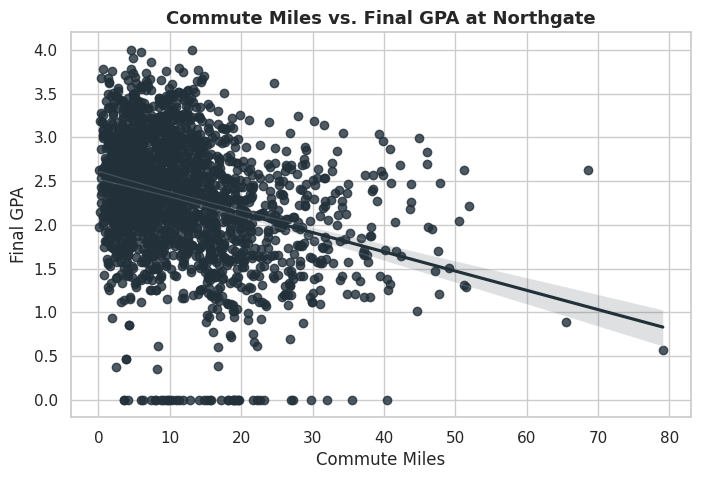

In [8]:
fig, ax = plt.subplots()
sns.regplot(data=students, x="commute_miles", y="final_gpa", color=NAVY, ax=ax)

ax.set_title("Commute Miles vs. Final GPA at Northgate")
ax.set_xlabel("Commute Miles")
ax.set_ylabel("Final GPA")
plt.show()

**STAR story — Q4**

**Scope —** This chart shows how commute distance relates to final GPA.

**Track —** This answers the question: "Is there a relationship between how far students commute and their final GPA?"

**Articulate —** There's a very slight negative trend: as commute distance increases, GPA tends to slightly decrease. However, the connection is weak, and many students with long commutes still have high GPAs. The data points are spread out, meaning there's no strong link.

**Respond —** The weak negative link suggests very long commutes might slightly affect GPA, perhaps due to less study time. But other factors likely influence GPA more. It would be useful to study this further by considering other factors like work or study hours to see if these factors explain the GPA differences and help us provide better support.

### Q5 · Over time
**How does student engagement change across the semester?**
→ *line chart* of average weekly activity. Use the `weekly` table: `week` and `minutes_active` (you'll need to average by week first — see the Guided notebook).

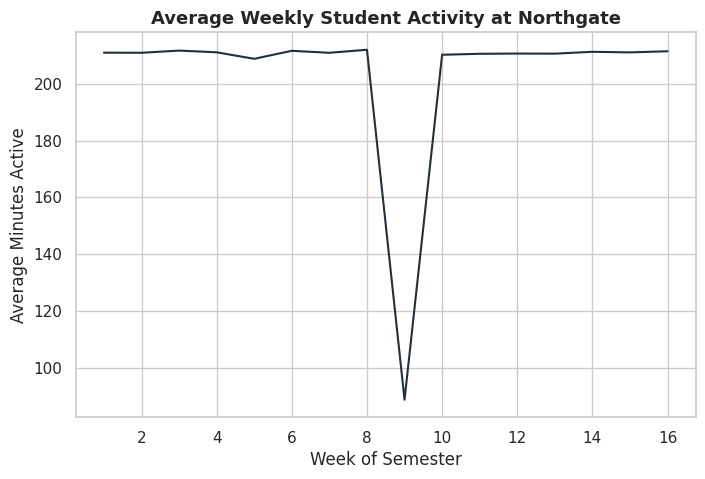

In [9]:
weekly_avg_activity = weekly.groupby('week')['minutes_active'].mean().reset_index()

fig, ax = plt.subplots()
sns.lineplot(data=weekly_avg_activity, x="week", y="minutes_active", color=NAVY, ax=ax)

ax.set_title("Average Weekly Student Activity at Northgate")
ax.set_xlabel("Week of Semester")
ax.set_ylabel("Average Minutes Active")
plt.show()

**STAR story — Q5**

**Scope —** This chart shows the average student activity in minutes per week over a semester.

**Track —** This answers the question: "How does student engagement change across the semester?"

**Articulate —** Student activity typically starts high, dips around mid-semester (weeks 7-8), and then increases towards the end, possibly during exam times. It shows fluctuating engagement rather than a steady change.

**Respond —** The dips in engagement might be times when students need more help. It would be helpful to connect these dips to the academic calendar (like midterms) to understand why they happen. We could also check if different student groups show different engagement patterns.

# Part B — Your own question (open)
Pose **one question of your own** about the Northgate students, choose the chart that answers it, build it, label it, and write its STAR story. Going beyond Part A is rewarded — a per-student line chart, a violin plot, or a chart of a messier column are all fair game.

**Your question:** Does housing status affect final GPA?



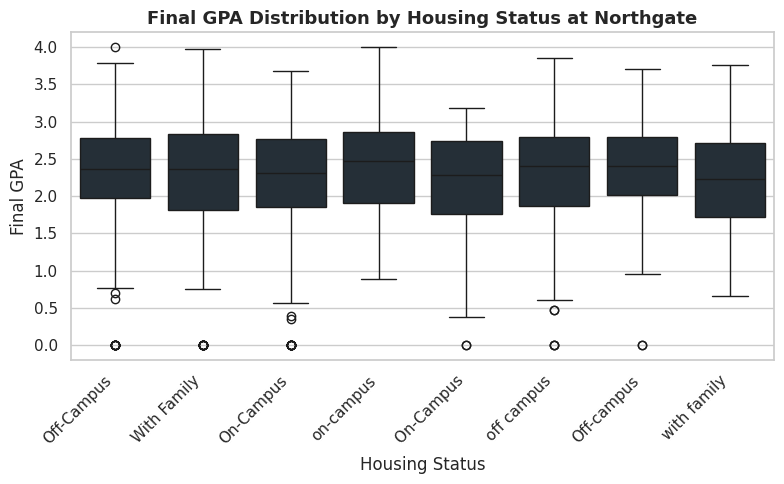

In [11]:
fig, ax = plt.subplots()
sns.boxplot(data=students, x="housing", y="final_gpa", color=NAVY, ax=ax)

ax.set_title("Final GPA Distribution by Housing Status at Northgate")
ax.set_xlabel("Housing Status")
ax.set_ylabel("Final GPA")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**STAR story — Part B**

**Scope —** This chart compares the final GPA of students based on where they live (On-Campus, Off-Campus, With Family).

**Track —** This answers the question: "Does housing status affect final GPA?"

**Articulate —** Students living On-Campus and Off-Campus have similar average GPAs. Students living With Family tend to have a slightly lower average GPA and a wider range of scores, including some lower ones. All groups have a similar spread of GPAs, but the With Family group shows a slightly lower spread.

**Respond —** The slightly lower average GPA for students living With Family could be due to more responsibilities, longer commutes, or less study time. Further study could look at their work hours, commute times, or study hours to see if these factors explain the GPA differences and help us provide better support.

# Before you submit — checklist
- [ ] The notebook **runs top to bottom** with no errors (Runtime → Restart and run all).
- [ ] All **6 charts** are present, each with a title, labeled axes, and units/legend where needed.
- [ ] Each chart has a **complete STAR story**, including any exceptions you spotted.
- [ ] Part B question is written in and answered.
- [ ] Pushed to **GitHub**, and the **GitHub link** is submitted in Canvas.

**Rubric (70 pts):** chart choice 10 · correct build 20 · labeling 10 · STAR reading 18 · Part B question 4 · submission & professionalism 8.